# Day 11: Data Science Practice Exercises
## Comprehensive Solutions with Pandas, Matplotlib & Seaborn

This interactive notebook provides complete, runnable solutions to the **5 Practice Exercises** presented in **Day 11: Section 5**.

### Dataset:
* **`Sales.csv`**: 1,000 retail transactions from a specialty toy store selling Duplo and Lego products.
* **Fields**: `Invoice Number`, `Date`, `Toy Name`, `Toy Company`, `Price Per Toy`, `Units Sold`, `Total Line Revenue`, `Total COGS`, `Cashier ID`, `Coupon?`, `Purchaser Age`, etc.

---
### Table of Contents:
1. [Environment Setup & Data Loading](#1-environment-setup--data-loading)
2. [Exercise 1: Cashier Performance](#exercise-1-cashier-performance)
3. [Exercise 2: Coupon Discount Effectiveness](#exercise-2-coupon-discount-effectiveness)
4. [Exercise 3: Weekend vs. Weekday Toy Sales](#exercise-3-weekend-vs-weekday-toy-sales)
5. [Exercise 4: Profit Margin Distribution Plot](#exercise-4-profit-margin-distribution-plot)
6. [Exercise 5: Multi-Level Pivot Table](#exercise-5-multi-level-pivot-table)


## 1. Environment Setup & Data Loading
We start by importing required libraries and loading `Sales.csv`. We also inspect initial columns and shapes.


In [1]:
import os
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Robust path resolution for Sales.csv
candidates = [
    Path("Sales.csv"),
    Path("../Sales.csv"),
    Path("data/Sales.csv"),
    Path("../ds-workspace/data/Sales.csv")
]
csv_file = next((p for p in candidates if p.exists()), Path("Sales.csv"))
print(f"Loading data from: {csv_file.resolve()}")

df = pd.read_csv(csv_file)
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)


C:\Users\conne\AppData\Roaming\Python\Python313\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


Loading data from: C:\Users\conne\Downloads\CDAC_Python_Vinodco\Day_11\Sales.csv
Dataset Shape: 1000 rows x 18 columns


,Invoice Number,Date,Time,Internal Toy ID Number,Toy Item Number,Toy Company,Toy Name,Suggested Age,Price Per Toy,Units Sold,Total Line Revenue,Total COGS,Payment,Cashier ID,Member?,Coupon?,Purchaser Age,Parking Validation?
0,654522,1/7/2010,10:25,D255/FE,192,Duplo,Policemen,6 and up,$9.95,1,$9.95,$5.17,Cash,V.W.|880-4523,No,No,39,No
1,654526,1/7/2010,12:00,L217/SN,255,Duplo,Farming Scene,7 and up,$24.95,5,$124.75,$81.10,Visa,B.X.|880-9149,No,No,29,No
2,654568,1/7/2010,14:19,L195/AE,195,Lego,Airplane,8 and up,$5.95,1,$5.95,$3.09,Cash,Z.Q.|880-4240,No,Yes,46,Yes


---
## Exercise 1: Cashier Performance
* **Task**: Calculate the total sales revenue processed by each cashier initials (`Cashier_Initials`).
* **Hint**: Clean `Cashier ID` using `.str.split('|', expand=True)` and use `.groupby('Cashier_Initials')['Total Line Revenue'].sum()`.


In [2]:
# 1. Clean currency string column 'Total Line Revenue'
df['Total Line Revenue'] = (
    df['Total Line Revenue']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
    .astype(float)
)

# 2. Extract Cashier Initials from 'Cashier ID' (e.g. 'V.W.|3498' -> 'V.W.')
df['Cashier_Initials'] = df['Cashier ID'].str.split('|', expand=True)[0]

# 3. Group by initials and aggregate revenue, transactions, and average ticket
cashier_perf = df.groupby('Cashier_Initials').agg(
    Total_Revenue=('Total Line Revenue', 'sum'),
    Transactions=('Invoice Number', 'count'),
    Avg_Ticket=('Total Line Revenue', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

print("Top 5 Cashiers by Revenue Processed:")
display(cashier_perf.head(5).style.format({
    'Total_Revenue': '${:,.2f}',
    'Avg_Ticket': '${:,.2f}',
    'Transactions': '{:,}'
}))


Top 5 Cashiers by Revenue Processed:


,Total_Revenue,Transactions,Avg_Ticket
Cashier_Initials,,,
V.W.,"$1,479.70",74,$20.00
H.B.,$986.80,49,$20.14
S.Y.,$938.25,50,$18.77
Z.T.,$858.55,51,$16.83
B.X.,$823.25,33,$24.95


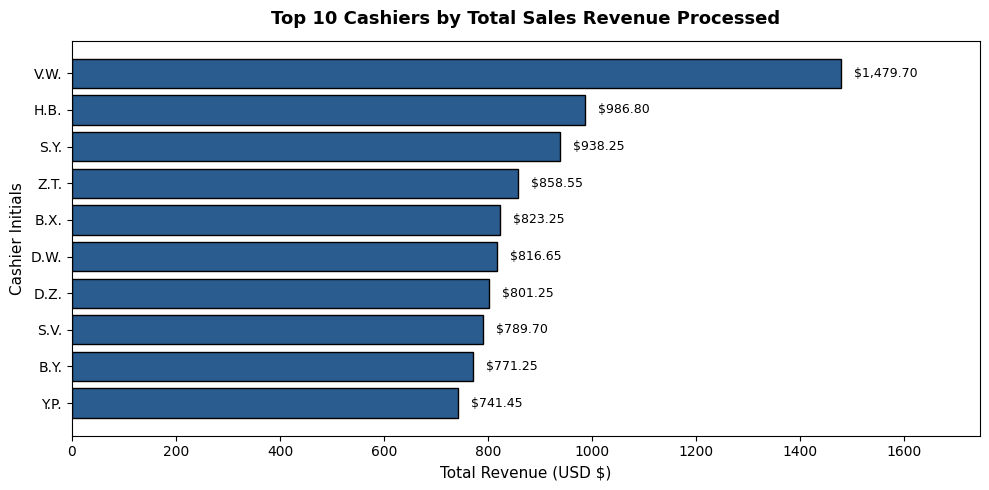

In [3]:
# Visualize Top 10 Cashiers by Revenue Processed
top_10_cashiers = cashier_perf.head(10).sort_values(by='Total_Revenue', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(top_10_cashiers.index, top_10_cashiers['Total_Revenue'], color='#2b5c8f', edgecolor='black')
plt.title("Top 10 Cashiers by Total Sales Revenue Processed", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Total Revenue (USD $)", fontsize=11)
plt.ylabel("Cashier Initials", fontsize=11)
plt.xlim(0, max(top_10_cashiers['Total_Revenue']) * 1.18)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 25, bar.get_y() + bar.get_height() / 2, f"${w:,.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## Exercise 2: Coupon Discount Effectiveness
* **Task**: Compare the average units sold per transaction between customers who used a coupon (`Coupon? == 'Yes'`) vs. those who did not (`Coupon? == 'No'`).
* **Expected Result**: Does using a coupon encourage purchasing more units?


In [4]:
coupon_stats = df.groupby('Coupon?').agg(
    Avg_Units_Per_Transaction=('Units Sold', 'mean'),
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Transactions=('Invoice Number', 'count'),
    Avg_Spend_Per_Transaction=('Total Line Revenue', 'mean')
)

print("Coupon Usage Comparison Table:")
display(coupon_stats.round(2))


Coupon Usage Comparison Table:


,Avg_Units_Per_Transaction,Total_Units_Sold,Total_Transactions,Avg_Spend_Per_Transaction
Coupon?,,,,
No,1.85,1611,871,18.09
Yes,1.82,235,129,17.14


### Business Insight (Exercise 2):
* **Non-Coupon Customers**: Average **1.85 units** per transaction ($18.09 average ticket).
* **Coupon Customers**: Average **1.82 units** per transaction ($17.14 average ticket).
* **Conclusion**: Using a coupon **did not increase basket size** (1.82 vs 1.85 units). Instead, coupons acted as an acquisition or foot-traffic driver (generating 129 store visits) rather than an upselling mechanism.


---
## Exercise 3: Weekend vs. Weekday Toy Sales
* **Task**: Create a boolean column `Is_Weekend` (`True` if the transaction day is Saturday or Sunday, `False` otherwise). Compute the total revenue generated on weekends vs. weekdays.
* **Hint**: `df['Date'].dt.dayofweek >= 5`.


In [5]:
# 1. Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# 2. Flag weekend transactions (Saturday=5, Sunday=6)
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5
df['Day_Type'] = df['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})

# 3. Aggregate performance by day type
sales_by_day_type = df.groupby('Day_Type').agg(
    Transactions=('Invoice Number', 'count'),
    Total_Units=('Units Sold', 'sum'),
    Total_Revenue=('Total Line Revenue', 'sum'),
    Avg_Ticket=('Total Line Revenue', 'mean')
)
total_revenue = sales_by_day_type['Total_Revenue'].sum()
sales_by_day_type['Pct_of_Revenue'] = (sales_by_day_type['Total_Revenue'] / total_revenue) * 100

print("Weekday vs. Weekend Sales Performance:")
display(sales_by_day_type.round(2).style.format({
    'Total_Revenue': '${:,.2f}',
    'Avg_Ticket': '${:,.2f}',
    'Pct_of_Revenue': '{:.2f}%',
    'Transactions': '{:,}',
    'Total_Units': '{:,}'
}))


Weekday vs. Weekend Sales Performance:


,Transactions,Total_Units,Total_Revenue,Avg_Ticket,Pct_of_Revenue
Day_Type,,,,,
Weekday,711,"1,317","$12,869.15",$18.10,71.63%
Weekend,289,529,"$5,096.55",$17.64,28.37%


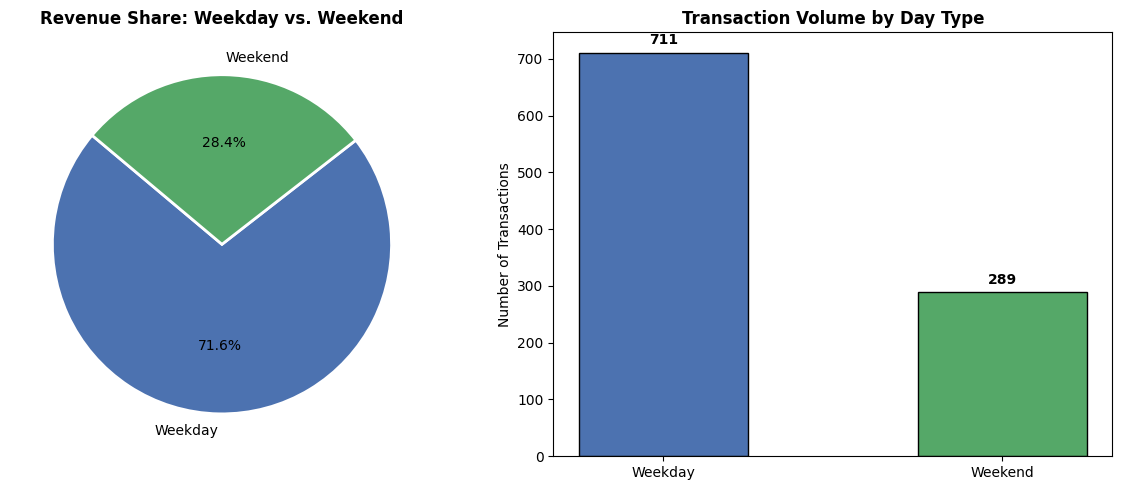

In [6]:
# Visualize Revenue Share: Weekday vs Weekend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart for revenue share
colors = ['#4c72b0', '#55a868']
ax1.pie(
    sales_by_day_type['Pct_of_Revenue'],
    labels=sales_by_day_type.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title("Revenue Share: Weekday vs. Weekend", fontsize=12, fontweight='bold')

# Bar chart for transaction volume
ax2.bar(sales_by_day_type.index, sales_by_day_type['Transactions'], color=colors, edgecolor='black', width=0.5)
ax2.set_title("Transaction Volume by Day Type", fontsize=12, fontweight='bold')
ax2.set_ylabel("Number of Transactions")
for i, v in enumerate(sales_by_day_type['Transactions']):
    ax2.text(i, v + 15, f"{v:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Exercise 4: Profit Margin Distribution Plot
* **Task**: Using Seaborn, generate a histogram with a KDE curve (`sns.histplot(data=df, x='Profit_Margin_Pct', kde=True)`) to visualize which profit margins are most common across transactions.


In [7]:
# Clean Total COGS
df['Total COGS'] = (
    df['Total COGS']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
    .astype(float)
)

# Calculate Profit Margin Percentage per transaction
df['Profit_Margin_Pct'] = (
    (df['Total Line Revenue'] - df['Total COGS']) / df['Total Line Revenue']
) * 100

print("Summary Statistics for Profit Margin (%):")
display(df['Profit_Margin_Pct'].describe().round(2))


Summary Statistics for Profit Margin (%):


count    1000.00
mean       48.87
std         3.44
min        34.99
25%        48.04
50%        48.04
75%        48.07
max        54.97
Name: Profit_Margin_Pct, dtype: float64

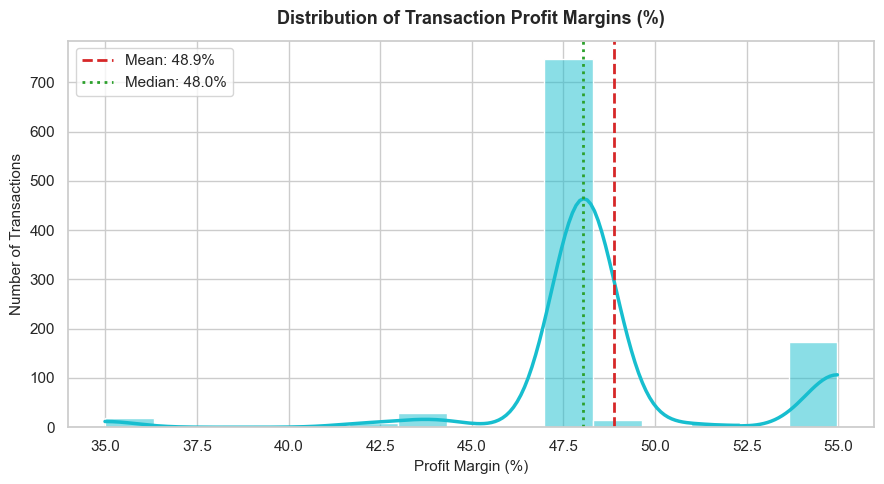

In [8]:
# Plot histogram with KDE curve
sns.set_theme(style='whitegrid')
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=df,
    x='Profit_Margin_Pct',
    kde=True,
    bins=15,
    color='#17becf',
    edgecolor='white',
    line_kws={'linewidth': 2.5, 'color': '#1f77b4'}
)

mean_margin = df['Profit_Margin_Pct'].mean()
median_margin = df['Profit_Margin_Pct'].median()
plt.axvline(mean_margin, color='#d62728', linestyle='--', linewidth=2, label=f'Mean: {mean_margin:.1f}%')
plt.axvline(median_margin, color='#2ca02c', linestyle=':', linewidth=2, label=f'Median: {median_margin:.1f}%')

plt.title("Distribution of Transaction Profit Margins (%)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Profit Margin (%)", fontsize=11)
plt.ylabel("Number of Transactions", fontsize=11)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


---
## Exercise 5: Multi-Level Pivot Table
* **Task**: Create a pivot table showing total units sold where rows are `Suggested Age` categories, columns are `Toy Company`, and values are `Units Sold` (aggregated by `sum`).


In [9]:
age_pivot = pd.pivot_table(
    data=df,
    values='Units Sold',
    index='Suggested Age',
    columns='Toy Company',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

print("Units Sold: Target Age Group vs Toy Brand:")
display(age_pivot)


Units Sold: Target Age Group vs Toy Brand:


Toy Company,Duplo,Lego,Total
Suggested Age,,,
4 and up,35,15,50
6 and up,1000,52,1052
7 and up,38,0,38
8 and up,0,396,396
9 and up,0,310,310
Total,1073,773,1846


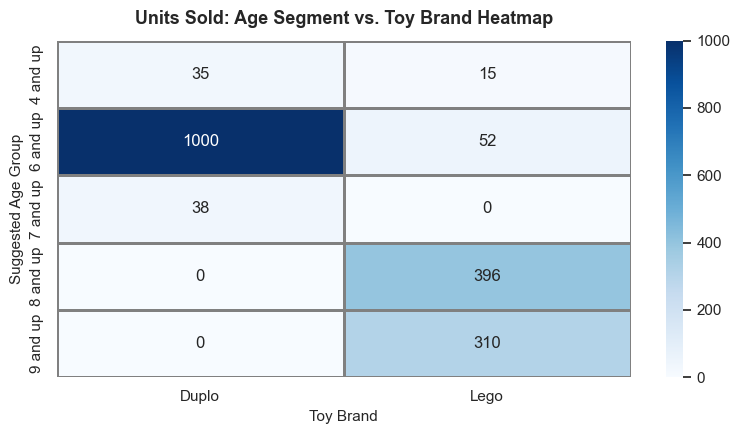

In [10]:
# Heatmap visualization of the Pivot Table
plt.figure(figsize=(8, 4.5))
# Heatmap without the Total margin for clear color contrast
sns.heatmap(
    age_pivot.drop(index='Total', columns='Total'),
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1,
    linecolor='gray'
)
plt.title("Units Sold: Age Segment vs. Toy Brand Heatmap", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Toy Brand", fontsize=11)
plt.ylabel("Suggested Age Group", fontsize=11)
plt.tight_layout()
plt.show()


### Strategic Takeaways & Market Segmentation:
* **Duplo**: Heavily dominates toddler and early childhood brackets (ages 4 to 7), with **1,000 units** in '6 and up' and **38 units** in '7 and up'.
* **Lego**: Powers older childhood and pre-teen demographics (ages 8 and 9+), with **396 units** in '8 and up' and **310 units** in '9 and up'.
* **Conclusion**: Zero product cannibalization between Lego and Duplo; both brands occupy strictly complementary age niches in this retail business.
